<a href="https://colab.research.google.com/github/tranquoctruong2503/THUCHANH_DEEPLEARNING/blob/main/ThucHanhBuoi03_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN

In [ ]:
#Khai bao thu vien
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input

import matplotlib.pyplot as plt


In [ ]:
#Doc du lieu
mnist_train ='/content/sample_data/mnist_train_small.csv'
mnist_test ='/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)


(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [ ]:
num_classes = 10
input_shape = (28,28,1)
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0],28,28,1)
print(X_train)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0],28,28,1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])


[[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.

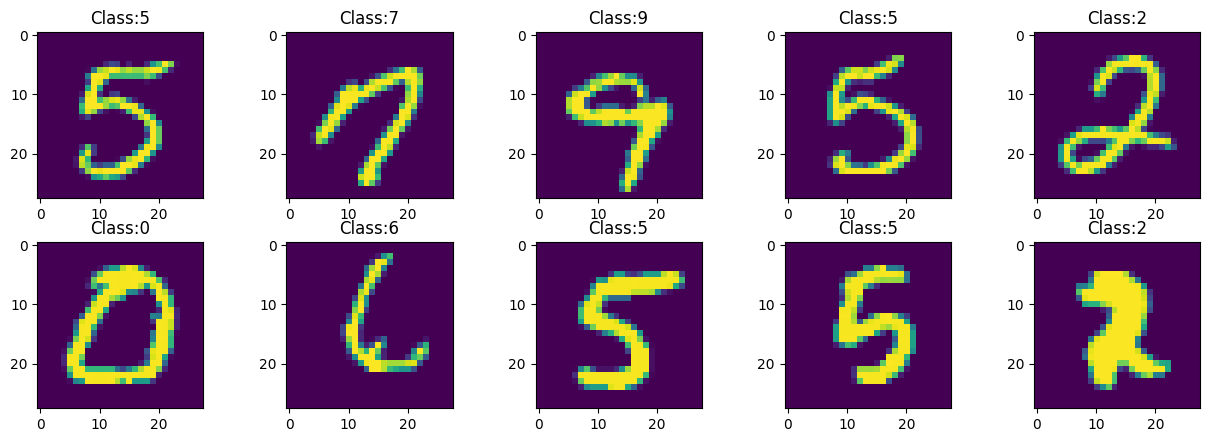

In [ ]:
# Truc quan hoa 10 anh dau tien
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28,28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(wspace=0.5)
plt.show()

In [ ]:
# Chuyen gia tri nhan thanh one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
# Xay dung mo hinh CNN
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units= 10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huan luyen CNN
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, verbose=1, validation_split=0.1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 161ms/step - accuracy: 0.8364 - loss: 0.6149 - val_accuracy: 0.9460 - val_loss: 0.2036
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.9593 - loss: 0.1411 - val_accuracy: 0.9585 - val_loss: 0.1277
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.9723 - loss: 0.0926 - val_accuracy: 0.9640 - val_loss: 0.1073
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.9773 - loss: 0.0720 - val_accuracy: 0.9725 - val_loss: 0.0905
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.9821 - loss: 0.0583 - val_accuracy: 0.9750 - val_loss: 0.0867
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.9835 - loss: 0.0508 - val_accuracy: 0.9780 - val_loss: 0.0717
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.9863 - loss: 0.0428 - val_accuracy: 0.9755 - val_loss: 0.0746
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.9898 - loss: 0.0336 

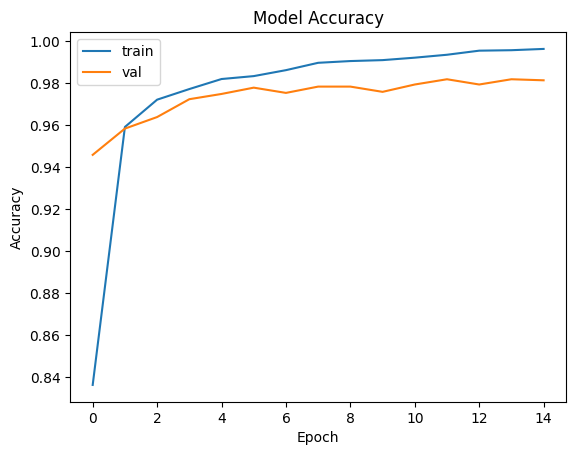

In [ ]:
# Danh gia CNN
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()

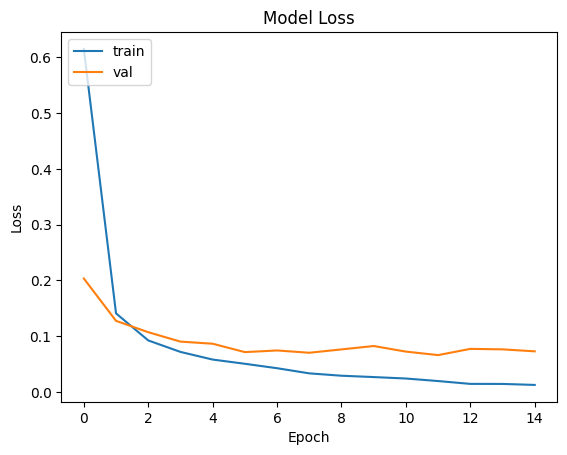

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()

In [ ]:
# Danh gia mo hinh CNN tren tap test
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 8ms/step - accuracy: 0.9827 - loss: 0.0591
Test loss: 0.05913614481687546
Test accuracy: 0.9826982617378235


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[4.4416538e-05 6.7189755e-03 9.9323612e-01 6.6355803e-11 1.7851125e-17
  7.8917461e-13 4.9887586e-07 1.7820721e-16 2.1068987e-09 1.5831856e-20]]
2 2


<function matplotlib.pyplot.show(close=None, block=None)>

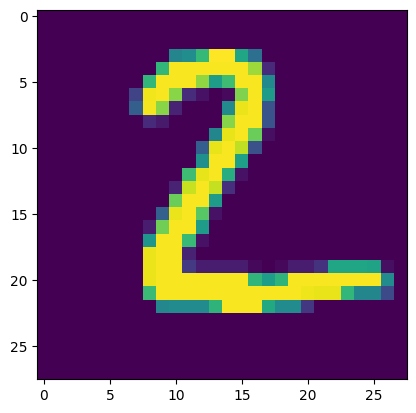

In [ ]:
# Du bao nhan cho anh CNN
predict = model.predict(X_test[:1])
print(predict)
print('Du doan:',np.argmax(predict),'Thuc te:' ,np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28,28))
plt.show

In [ ]:
#Luu tham so mo hinh CNN
model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
[[7.3154702e-08 9.9986207e-01 2.2622593e-05 5.1864259e-08 8.6488188e-05
  1.0184109e-07 3.4277423e-07 1.8117156e-05 1.0157019e-05 1.1407716e-09]]
Du doan: 1 Thuc te: 1


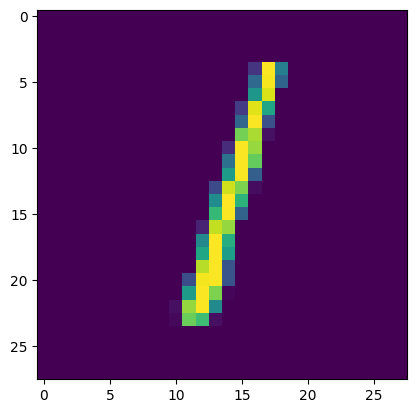

In [ ]:
# Nap lai mo hinh va tham so
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units= 10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print('Du doan:',np.argmax(predict), 'Thuc te:', np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28,28))
plt.show()

BÀI TẬP

In [ ]:
# Khai bao thu vien
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt
from keras.datasets import cifar10

In [ ]:
# Doc du lieu
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [ ]:
# Tien xu ly du lieu
num_classes = 10
input_shape = (32, 32, 3)

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
[[6]
 [9]
 [9]
 [4]
 [1]]


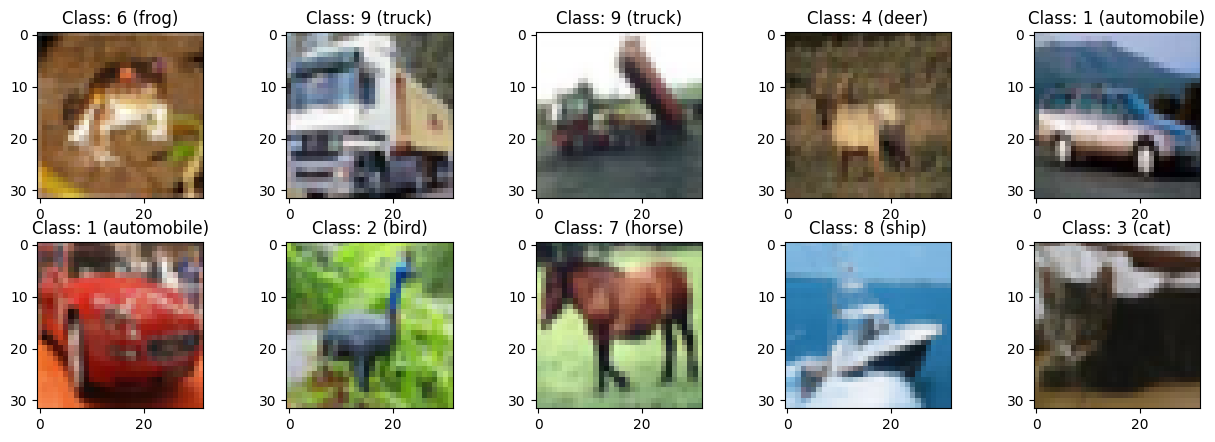

In [ ]:
# Truc quan hoa 10 anh dau tien
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i])
    label_index = int(y_train[i][0])
    ax[i].title.set_text(f'Class: {label_index} ({class_names[label_index]})')
plt.subplots_adjust(wspace=0.5)
plt.show()

In [ ]:
# Chuyen gia tri nhan thanh one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
# Xay dung mo hinh CNN
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huan luyen CNN
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, verbose=1, validation_split=0.1)


Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 138ms/step - accuracy: 0.4088 - loss: 1.6580 - val_accuracy: 0.5044 - val_loss: 1.4212
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 46s 131ms/step - accuracy: 0.5333 - loss: 1.3288 - val_accuracy: 0.5648 - val_loss: 1.2424
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 83s 134ms/step - accuracy: 0.5821 - loss: 1.2068 - val_accuracy: 0.6018 - val_loss: 1.1616
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 46s 131ms/step - accuracy: 0.6112 - loss: 1.1201 - val_accuracy: 0.6208 - val_loss: 1.1081
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.6342 - loss: 1.0610 - val_accuracy: 0.6234 - val_loss: 1.0842
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 130ms/step - accuracy: 0.6477 - loss: 1.0220 - val_accuracy: 0.6558 - val_loss: 1.0306
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.6619 - loss: 0.9867 - val_accuracy: 0.6598 - val_loss: 0.9940
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 133ms/step - accuracy: 0.6741 - loss: 0

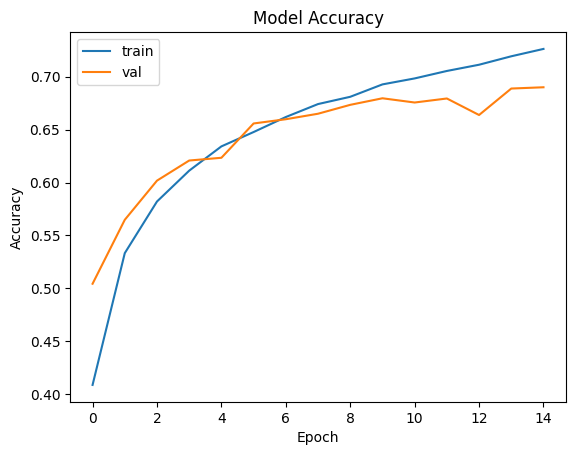

In [ ]:
# Danh gia CNN
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


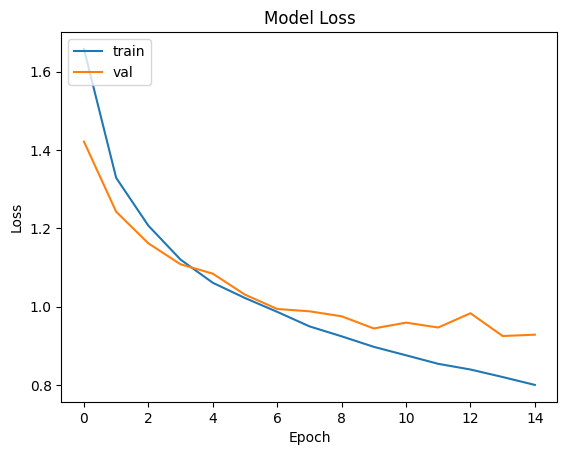

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()



In [ ]:
# Danh gia mo hinh CNN tren tap test
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])



313/313 - 3s - 10ms/step - accuracy: 0.6738 - loss: 0.9622
Test loss: 0.962224006652832
Test accuracy: 0.673799991607666


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[6.5010722e-04 1.9644189e-04 7.7789654e-03 7.4560654e-01 5.1937797e-03
  1.4775313e-01 6.8773359e-02 5.9229246e-04 2.1396626e-02 2.0587787e-03]]
Dự đoán: 3 (cat) | Thực tế: 3 (cat)


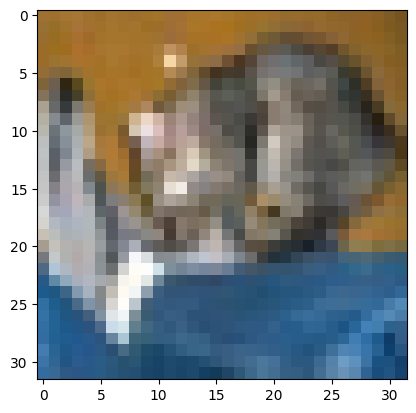

In [ ]:
# Du bao nhan cho anh CNN
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predict = model.predict(X_test[0:1])
print(predict)

pred_idx = np.argmax(predict)
true_idx = np.argmax(y_test[0])

print(f"Dự đoán: {pred_idx} ({class_names[pred_idx]}) | Thực tế: {true_idx} ({class_names[true_idx]})")

# Hiển thị ảnh kèm theo tiêu đề là tên dự đoán để dễ nhìn hơn
plt.imshow(X_test[0])
plt.show()


In [ ]:
# Luu tham so mo hinh CNN
model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[[6.5010722e-04 1.9644189e-04 7.7789654e-03 7.4560654e-01 5.1937797e-03
  1.4775313e-01 6.8773359e-02 5.9229246e-04 2.1396626e-02 2.0587787e-03]]
Dự đoán: 1 (automobile) | Thực tế: 8 (ship)


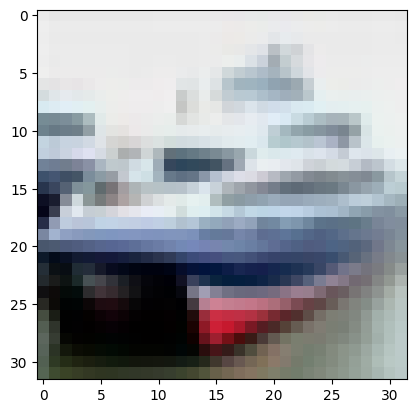

In [ ]:
# Nap lai mo hinh va tham so
model_reloaded = Sequential()
model_reloaded.add(Input(shape=input_shape))
model_reloaded.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2,2)))
model_reloaded.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2,2)))
model_reloaded.add(Flatten())
model_reloaded.add(Dense(units=10, activation='softmax'))

model_reloaded.load_weights('cnn.weights.h5')

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predict2 = model.predict(X_test[1:2])
print(predict)

pred_idx = np.argmax(predict2)
true_idx = np.argmax(y_test[1])

print(f"Dự đoán: {pred_idx} ({class_names[pred_idx]}) | Thực tế: {true_idx} ({class_names[true_idx]})")

# Hiển thị ảnh kèm theo tiêu đề là tên dự đoán để dễ nhìn hơn
plt.imshow(X_test[1])
plt.show()